In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import os
from pathlib import Path
import warnings
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Polygon
from matplotlib.path import Path
import matplotlib.patches as patches

In [ ]:
def get_s2s_prob_twice_weekly(yr, data_dir):
    """
    Loads model precip data for twice-weekly initializations from May to July.
    Filters for Mondays and Thursdays in the specified year.
    The forecast file is expected to be named as '{year}.nc' in the data_dir with 
    variable "tp" being daily accumulated rainfall with dimensions (init_time, lat, lon, step, member).

    Parameters:
    yr: int, year to load data for
    
    Returns:
    p_model: ndarray, precipitation data 
    """
    fname = f'tp_2p0_{yr}.nc'
    file_path = os.path.join(data_dir, fname)
        
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File not found: {file_path}")
        
    # Filter for twice weekly data from daily for the specified year
    start_date = datetime(2024, 5, 1)
    end_date = datetime(2024, 7, 31)
    date_range = pd.date_range(start_date, end_date, freq='D')
        
    # Find Mondays and Thursdays
    is_monday = date_range.weekday == 0
    is_thursday = date_range.weekday == 3
    filtered_dates = date_range[is_monday | is_thursday]
    filtered_dates_yr = pd.to_datetime(filtered_dates.strftime(f'{yr}-%m-%d'))
        
    # Load data using xarray
    ds = xr.open_dataset(file_path)
    if 'time' in ds.dims:
        ds = ds.rename({'time': 'init_time'})
    if 'number' in ds.dims:
        ds = ds.rename({'number': 'member'})
    # Find common dates between desired dates and available dates
    available_init_times = pd.to_datetime(ds.init_time.values)
    matching_times = available_init_times[available_init_times.isin(filtered_dates_yr)]
        
    if len(matching_times) == 0:
        raise ValueError(f"No matching initialization times found for year {yr}")
        
    # Select only the matching initialization times
    ds = ds.sel(init_time=matching_times)
    if 'day' in ds.dims:
        # Check if the first value of 'day' is 0, then slice to exclude it
        if ds['day'][0].values == 0:
            ds = ds.sel(day=slice(1, None))
    # Check if 'step' dimension exists and conditionally slice
    if 'step' in ds.dims:
        # Check if the first value of 'step' is 0, then slice to exclude it
        if ds['step'][0].values == 0:
            ds = ds.sel(step=slice(1, None)) 
    if 'day' in ds.dims:        
        ds = ds.rename({'day': 'step'})
    
    p_model = ds['tp']  # in mm    
    ds.close()
    return p_model

In [ ]:
def load_imd_rainfall(year, imd_folder):
    """
    Load IMD daily rainfall NetCDF for a given year.
    Handles different file naming conventions and standardizes dimension names.

    Parameters
    ----------
    imd_folder : str
        Folder containing IMD NetCDF files. Files can be named either:
        - 'data_YYYY.nc' (for 2-degree resolution)
        - 'YYYY.nc' (for 4-degree resolution)
    year : int
        Year to load.

    Returns
    -------
    rainfall_ds : xarray.DataArray
        IMD rainfall data with standardized dims ['lat','lon','time'].
    """
    # Try different file naming conventions
    file_patterns = [f"data_{year}.nc", f"{year}.nc"]
    
    imd_file = None
    for pattern in file_patterns:
        test_path = f"{imd_folder}/{pattern}"
        if os.path.exists(test_path):
            imd_file = test_path
            break
    
    if imd_file is None:
        available_files = [f for f in os.listdir(imd_folder) if f.endswith('.nc')]
        raise FileNotFoundError(
            f"No IMD file found for year {year} in {imd_folder}. "
            f"Tried patterns: {file_patterns}. "
            f"Available files: {available_files}"
        )
    
    print(f"Loading IMD rainfall from: {imd_file}")
    
    ds = xr.open_dataset(imd_file)
    rainfall = ds['RAINFALL']
    
    # Standardize dimension names
    dim_mapping = {}
    
    # Check for latitude/longitude dimensions
    # Check for latitude/longitude dimensions
    if 'latitude' in rainfall.dims:
        dim_mapping['latitude'] = 'lat'
    if 'LATITUDE' in rainfall.dims:
        dim_mapping['LATITUDE'] = 'lat'
    if 'longitude' in rainfall.dims:
        dim_mapping['longitude'] = 'lon'
    if 'LONGITUDE' in rainfall.dims:
        dim_mapping['LONGITUDE'] = 'lon'
    if 'TIME' in rainfall.dims:
        dim_mapping['TIME'] = 'time'
    
    # Apply renaming if any mappings found
    if dim_mapping:
        rainfall = rainfall.rename(dim_mapping)
        print(f"Renamed dimensions: {dim_mapping}")
    else:
        print(f"No dimension renaming needed. Current dims: {list(rainfall.dims)}")
    
    return rainfall

In [4]:
#### functions to detect observed onset dates ####
def detect_observed_onset(rainfall_ds, thresh_slice, year, mok=True):
    """
    Detect observed onset dates for a given year.
    
    Parameters:
    rainfall_ds: xarray DataArray with rainfall data
    thresh_slice: xarray DataArray with threshold values
    year: int, year to process
    mok: bool, if True use June 2nd as start date (MOK), if False use May 1st
    
    Returns:
    onset_da: xarray DataArray with onset dates
    """
    # Subset rainfall data
    rain_slice = rainfall_ds
    
    # Parameters
    window = 5
    
    # Set start date based on mok flag
    if mok:
        start_date = datetime(year, 6, 2)  # MOK date: June 2nd
        date_label = "MOK date (June 2nd)"
    else:
        start_date = datetime(year, 5, 1)  # May 1st
        date_label = "May 1st"

    # Find start date index
    time_dates = pd.to_datetime(rain_slice.time.values)
    start_idx_candidates = np.where(time_dates > start_date)[0]
    
    if len(start_idx_candidates) == 0:
        print(f"Warning: {date_label} ({start_date.strftime('%Y-%m-%d')}) not found in data for year {year}")
        # Fallback to April 1st if start date not available
        fallback_date = datetime(year, 4, 1)
        start_idx = np.where(time_dates >= fallback_date)[0][0]
        print(f"Using fallback date: April 1st")
    else:
        start_idx = start_idx_candidates[0]
        print(f"Using {date_label} ({start_date.strftime('%Y-%m-%d')}) as start date for onset detection")

    # Subset rain_slice from start date onward
    rain_subset = rain_slice.isel(time=slice(start_idx, None))

    # Create rolling 5-day sums
    rolling_sum = rain_subset.rolling(time=window, min_periods=window, center=False).sum()
    rolling_sum_aligned = rolling_sum.shift(time=-(window-1))

    # Create onset condition
    first_day_condition = rain_subset > 1
    sum_condition = rolling_sum_aligned > thresh_slice
    onset_condition = first_day_condition & sum_condition

    # Find first occurrence of onset condition for each grid point
    def find_first_true(arr):
        if arr.any():
            return int(np.argmax(arr))
        else:
            return -1

    onset_indices = xr.apply_ufunc(
        find_first_true,
        onset_condition,
        input_core_dims=[['time']],
        output_dtypes=[int],
        vectorize=True
    )

    # Convert indices to actual dates
    valid_mask = onset_indices.values >= 0
    time_coords = rain_subset.time.values
    onset_dates_array = np.full(onset_indices.shape, np.datetime64('NaT'), dtype='datetime64[ns]')

    for i in range(onset_indices.shape[0]):
        for j in range(onset_indices.shape[1]):
            if valid_mask[i, j]:
                idx = int(onset_indices[i, j].values)
                if 0 <= idx < len(time_coords):
                    onset_dates_array[i, j] = time_coords[idx]

    # Create final onset date DataArray
    onset_da = xr.DataArray(
        onset_dates_array,
        coords=[('lat', rain_slice.lat.values), ('lon', rain_slice.lon.values)],
        name='onset_date'
    )
    
    return onset_da

In [5]:
def compute_mean_onset_for_all_members(p_model, thresh_slice, onset_da, max_forecast_day=15, mok=True):
    """
    Compute onset dates for each ensemble member, initialization time, and grid point.
    Only processes forecasts initialized before the observed onset date.
    For each initialization, requires at least 50% of members to have onset.
    If threshold met, uses ceiling of mean onset day as the ensemble onset.
    
    Parameters:
    p_model: xarray DataArray with dims [init_time, step, lat, lon, member]
    thresh_slice: xarray DataArray with threshold values for each grid point
    onset_da: xarray DataArray with observed onset dates for filtering
    max_forecast_day: int, maximum forecast day to consider for onset (default 15)
    mok: bool, if True only count onset after June 2nd (MOK date), if False use all forecasts
    
    Returns:
    pandas DataFrame with columns: init_time, lat, lon, onset_day, member_onset_count, total_members
    """
    
    window = 5
    results_list = []
    
    # Get dimensions
    init_times = p_model.init_time.values
    lats = p_model.lat.values  
    lons = p_model.lon.values
    members = p_model.member.values
    
    date_method = "MOK (June 2nd filter)" if mok else "no date filter"
    print(f"Processing {len(init_times)} init times x {len(lats)} lats x {len(lons)} lons...")
    print(f"Using {date_method} for onset detection")
    print(f"Only processing forecasts initialized before observed onset dates")
    print(f"Requiring ≥50% of {len(members)} members to have onset for ensemble onset")
    
    # We need first 19 days to check onset up to day 15 (because of 5-day window)
    max_steps_needed = max_forecast_day + window - 1
    
    # Track statistics
    total_potential_inits = 0
    valid_inits = 0
    skipped_no_obs = 0
    skipped_late_init = 0
    ensemble_onsets_found = 0
    
    # Loop over all combinations
    for t_idx, init_time in enumerate(init_times):
        if t_idx % 5 == 0:  # Print progress every 5 init times
            print(f"Processing init time {t_idx+1}/{len(init_times)}: {pd.to_datetime(init_time).strftime('%Y-%m-%d')}")
        
        # Get init date for MOK filtering and onset comparison
        init_date = pd.to_datetime(init_time)
        year = init_date.year
        mok_date = datetime(year, 6, 2)  # June 2nd of the same year
        
        for i, lat in enumerate(lats):
            for j, lon in enumerate(lons):
                
                total_potential_inits += 1
                
                # Get observed onset date for this grid point
                try:
                    obs_onset = onset_da.isel(lat=i, lon=j).values
                except:
                    skipped_no_obs += 1
                    continue
                
                # Skip if no observed onset
                if pd.isna(obs_onset):
                    skipped_no_obs += 1
                    continue
                
                # Convert observed onset to datetime
                obs_onset_dt = pd.to_datetime(obs_onset)
                
                # Only process if forecast was initialized before observed onset
                if init_date >= obs_onset_dt:
                    skipped_late_init += 1
                    continue
                
                valid_inits += 1
                
                # Get threshold for this grid point
                thresh = thresh_slice.isel(lat=i, lon=j).values
                
                # Collect onset days for all members at this init/location
                member_onset_days = []
                
                for m_idx, member in enumerate(members):
                    try:
                        # Extract forecast time series for this member
                        forecast_series = p_model.isel(
                            init_time=t_idx,
                            lat=i, 
                            lon=j,
                            member=m_idx,
                        ).sel(step=slice(1, max_steps_needed)).values
                        
                        if len(forecast_series) < max_steps_needed:
                            member_onset_days.append(None)
                            continue
                        
                        # Check for onset on each possible day
                        member_onset_day = None
                        
                        for day in range(1, max_forecast_day + 1):
                            start_idx = day - 1
                            end_idx = start_idx + window 

                            if end_idx <= len(forecast_series):
                                window_series = forecast_series[start_idx:end_idx]
                                
                                # Check basic onset condition: first day > 1mm AND 5-day sum > threshold
                                if window_series[0] > 1 and np.nansum(window_series) > thresh:
                                    
                                    # Calculate the actual date this forecast day represents
                                    forecast_date = init_date + pd.Timedelta(days=day)
                                    
                                    # If MOK flag is True, only count onset if it's on or after June 2nd
                                    if mok:
                                        if forecast_date.date() > mok_date.date():
                                            member_onset_day = day
                                            break  # Found valid onset after MOK date
                                        # else: continue checking later days
                                    else:
                                        # No MOK filtering, count this onset
                                        member_onset_day = day
                                        break
                        
                        member_onset_days.append(member_onset_day)
                        
                    except Exception as e:
                        print(f"Error at init_time {t_idx}, lat {i}, lon {j}, member {m_idx}: {e}")
                        member_onset_days.append(None)
                
                # Now check if at least 50% of members have onset
                valid_onsets = [day for day in member_onset_days if day is not None]
                onset_count = len(valid_onsets)
                total_members = len(member_onset_days)
                onset_percentage = onset_count / total_members if total_members > 0 else 0
                
                # Determine ensemble onset day
                ensemble_onset_day = None
                ensemble_onset_date = None
                if onset_percentage >= 0.5:  # At least 50% of members have onset
                    # Use rounding of mean onset day
                    mean_onset = np.mean(valid_onsets)
                    ensemble_onset_day = int(round(mean_onset))
                    ensemble_onsets_found += 1
                    ensemble_onset_date = init_date + pd.Timedelta(days=ensemble_onset_day)
                
                # Store result
                result = {
                    'init_time': init_time,
                    'lat': lat,
                    'lon': lon,
                    'onset_day': ensemble_onset_day,  # None if <50% members have onset
                    'onset_date': ensemble_onset_date.strftime('%Y-%m-%d') if ensemble_onset_date is not None else None,
                    'member_onset_count': onset_count,
                    'total_members': total_members,
                    'onset_percentage': onset_percentage,
                    'obs_onset_date': obs_onset_dt.strftime('%Y-%m-%d')  # Store observed onset for reference
                }
                results_list.append(result)
    
    # Convert to DataFrame
    onset_df = pd.DataFrame(results_list)
    
    print(f"\nProcessing Summary:")
    print(f"Total potential initializations: {total_potential_inits}")
    print(f"Skipped (no observed onset): {skipped_no_obs}")
    print(f"Skipped (initialized after observed onset): {skipped_late_init}")
    print(f"Valid initializations processed: {valid_inits}")
    print(f"Ensemble onsets found (≥50% members): {ensemble_onsets_found}")
    print(f"Ensemble onset rate: {ensemble_onsets_found/valid_inits:.3f}" if valid_inits > 0 else "Ensemble onset rate: 0.000")
    
    if mok:
        print(f"Note: Only onsets on or after June 2nd were counted due to MOK flag")
    
    return onset_df

In [6]:
def compute_onset_metrics_with_windows(onset_df, tolerance_days=5, verification_window=1, forecast_days=15):
    """
    Compute confusion matrix metrics following MATLAB logic with forecast and validation windows.
    
    Parameters:
    onset_df: pandas DataFrame, output from compute_mean_onset_for_all_members
    tolerance_days: int, tolerance in days for considering a prediction as correct (default 5)
    verification_window: int, days after init to start validation window (default 1)
    forecast_days: int, length of forecast window in days (default 15)
    
    Returns:
    metrics_df: pandas DataFrame with metrics for each grid point
    summary_stats: dict with overall statistics
    """
    
    print(f"Computing onset metrics with tolerance = {tolerance_days} days")
    print(f"Verification window starts {verification_window} days after initialization")
    print(f"Forecast window length: {forecast_days} days")
    
    # Initialize results list
    results_list = []
    
    # Get unique grid points
    unique_locations = onset_df[['lat', 'lon']].drop_duplicates()
    
    print(f"Processing {len(unique_locations)} unique grid points...")
    
    for idx, (_, row) in enumerate(unique_locations.iterrows()):
        lat, lon = row['lat'], row['lon']
        
        if idx % 10 == 0:  # Progress update
            print(f"Processing grid point {idx+1}/{len(unique_locations)}: lat={lat:.2f}, lon={lon:.2f}")
        
        # Get all data for this grid point
        grid_data = onset_df[(onset_df['lat'] == lat) & (onset_df['lon'] == lon)].copy()
        
        # Convert date strings to datetime for calculation
        grid_data['obs_onset_dt'] = pd.to_datetime(grid_data['obs_onset_date'])
        grid_data['model_onset_dt'] = pd.to_datetime(grid_data['onset_date'])
        grid_data['init_dt'] = pd.to_datetime(grid_data['init_time'])
        
        # Initialize counters
        TP = 0
        FP = 0 
        FN = 0
        TN = 0
        num_onset = 0
        num_no_onset = 0
        mae_tp = []
        mae_fp = []
        
        # Get observed onset date (should be same for all rows)
        gt_grd = grid_data['obs_onset_dt'].iloc[0]  # Ground truth grid
        
        # Create true onset window
        true_onset_window_start = gt_grd - pd.Timedelta(days=tolerance_days)
        true_onset_window_end = gt_grd + pd.Timedelta(days=tolerance_days)
        
        # Process each initialization
        for _, init_row in grid_data.iterrows():
            t_init = init_row['init_dt']
            model_onset = init_row['model_onset_dt']
            
            # Define forecast windows (corrected logic)
            valid_window_start = t_init + pd.Timedelta(days=verification_window)
            valid_window_end = valid_window_start + pd.Timedelta(days=14)  # Always 15 days long
            
            whole_forecast_window_start = t_init + pd.Timedelta(days=1)
            whole_forecast_window_end = t_init + pd.Timedelta(days=forecast_days)  # Use forecast_days directly
            
            # Check if true onset is within whole forecast window
            is_onset_in_whole_window = whole_forecast_window_start <= gt_grd <= whole_forecast_window_end
            if is_onset_in_whole_window:
                num_onset += 1
            else:
                num_no_onset += 1
            
            # Check if model predicted onset
            has_model_onset = not pd.isna(model_onset)
            
            if has_model_onset:
                # Model had onset - check if it's within validation window
                is_model_in_valid_window = valid_window_start <= model_onset <= valid_window_end
                
                if is_model_in_valid_window:
                    # Model onset was within validation window
                    abs_diff_days = abs((model_onset - gt_grd).days)
                    
                    if abs_diff_days <= tolerance_days:
                        TP += 1
                        mae_tp.append(abs_diff_days)
                    else:
                        FP += 1
                        mae_fp.append(abs_diff_days)
                # If model onset outside validation window, it's not counted as TP or FP
                        
            else:
                # Model had no onset
                if is_onset_in_whole_window:
                    # True onset was within whole forecast window but model missed it
                    FN += 1
                else:
                    # True onset was outside whole forecast window and model correctly had no onset
                    TN += 1
        
        # Calculate metrics
        total_forecasts = len(grid_data)
        
        # Mean Absolute Error (combining TP and FP as in MATLAB)
        mae_combined = mae_tp + mae_fp
        mae = np.mean(mae_combined) if len(mae_combined) > 0 else np.nan
        mae_tp_only = np.mean(mae_tp) if len(mae_tp) > 0 else np.nan
        
        # Store results
        result = {
            'lat': lat,
            'lon': lon,
            'total_forecasts': total_forecasts,
            'true_positive': TP,
            'true_negative': TN,
            'false_positive': FP,
            'false_negative': FN,
            'num_onset': num_onset,
            'num_no_onset': num_no_onset,
            'mae_combined': mae,  # MAE combining TP and FP errors
            'mae_tp_only': mae_tp_only,  # MAE for true positives only
            'num_tp_errors': len(mae_tp),
            'num_fp_errors': len(mae_fp),
            'tolerance_days': tolerance_days,
            'verification_window': verification_window,
            'forecast_days': forecast_days
        }
        results_list.append(result)
    
    # Convert to DataFrame
    metrics_df = pd.DataFrame(results_list)
    
    # Calculate summary statistics
    summary_stats = {
        'total_grid_points': len(metrics_df),
        'total_forecasts': metrics_df['total_forecasts'].sum(),
        'overall_true_positive': metrics_df['true_positive'].sum(),
        'overall_true_negative': metrics_df['true_negative'].sum(),
        'overall_false_positive': metrics_df['false_positive'].sum(),
        'overall_false_negative': metrics_df['false_negative'].sum(),
        'overall_num_onset': metrics_df['num_onset'].sum(),
        'overall_num_no_onset': metrics_df['num_no_onset'].sum(),
        'overall_mae_combined': metrics_df['mae_combined'].mean(),
        'overall_mae_tp_only': metrics_df['mae_tp_only'].mean(),
        'tolerance_days': tolerance_days,
        'verification_window': verification_window,
        'forecast_days': forecast_days
    }
    
    # Calculate overall metrics
    total_tp = summary_stats['overall_true_positive']
    total_tn = summary_stats['overall_true_negative']
    total_fp = summary_stats['overall_false_positive']
    total_fn = summary_stats['overall_false_negative']
    
    print(f"\n=== SUMMARY STATISTICS ===")
    print(f"Tolerance: {tolerance_days} days")
    print(f"Verification window: {verification_window} days after init")
    print(f"Forecast window: {forecast_days} days")
    print(f"Total grid points: {summary_stats['total_grid_points']}")
    print(f"Total forecasts: {summary_stats['total_forecasts']}")
    print(f"Overall TP: {total_tp}, TN: {total_tn}, FP: {total_fp}, FN: {total_fn}")
    print(f"Onset cases: {summary_stats['overall_num_onset']}, No-onset cases: {summary_stats['overall_num_no_onset']}")
    print(f"Mean MAE (combined TP+FP): {summary_stats['overall_mae_combined']:.2f} days")
    print(f"Mean MAE (TP only): {summary_stats['overall_mae_tp_only']:.2f} days")
    
    return metrics_df, summary_stats

In [7]:
# Function to compute metrics for multiple years
def compute_metrics_multiple_years(years, s2s_data_dir, imd_folder, thres_file, 
                                 tolerance_days=3, verification_window=1, forecast_days=15, 
                                 max_forecast_day=15, mok=True):
    """
    Compute onset metrics for multiple years.
    
    Returns:
    metrics_df_dict: dict, {year: metrics_df}
    onset_da_dict: dict, {year: onset_da}
    """
    
    metrics_df_dict = {}
    onset_da_dict = {}
    
    # Load threshold data (same for all years)
    thresh_ds = xr.open_dataset(thres_file)
    thres_da = thresh_ds['MWmean']
    
    for year in years:
        print(f"\n{'='*50}")
        print(f"Processing year {year}")
        print(f"{'='*50}")
        
        # Load data for this year
        p_model = get_s2s_prob_twice_weekly(year, s2s_data_dir)
        imd = load_imd_rainfall(year, imd_folder)
        onset_da = detect_observed_onset(imd, thres_da, year, mok=mok)
        
        # Compute onset predictions
        onset_df = compute_mean_onset_for_all_members(
            p_model, thres_da, onset_da, 
            max_forecast_day=max_forecast_day, mok=mok
        )
        
        # Compute metrics
        metrics_df, summary_stats = compute_onset_metrics_with_windows(
            onset_df, 
            tolerance_days=tolerance_days, 
            verification_window=verification_window, 
            forecast_days=forecast_days
        )
        
        # Store results
        metrics_df_dict[year] = metrics_df
        onset_da_dict[year] = onset_da
        
        print(f"Year {year} completed. Grid points processed: {len(metrics_df)}")
    
    return metrics_df_dict, onset_da_dict

In [8]:
def create_spatial_far_mr_mae(metrics_df_dict, onset_da_dict):
    """
    Create spatial maps of False Alarm Rate, Miss Rate, yearly MAE, and mean MAE across years.
    
    Parameters:
    metrics_df_dict: dict, {year: metrics_df} from compute_onset_metrics_with_windows
    onset_da_dict: dict, {year: onset_da} observed onset dates for each year
    
    Returns:
    spatial_metrics: dict with FAR, Miss Rate, yearly MAE, and mean MAE maps
    """
    
    # Get coordinates from any onset_da (they should all have the same grid)
    first_year = list(onset_da_dict.keys())[0]
    lats = onset_da_dict[first_year].lat.values
    lons = onset_da_dict[first_year].lon.values
    
    print(f"Creating spatial FAR, Miss Rate, yearly MAE, and mean MAE maps...")
    print(f"Grid dimensions: {len(lats)} lats x {len(lons)} lons")
    print(f"Years: {list(metrics_df_dict.keys())}")
    
    # Initialize output dictionary
    spatial_metrics = {}
    
    # Initialize maps
    false_alarm_rate_map = np.full((len(lats), len(lons)), np.nan)
    miss_rate_map = np.full((len(lats), len(lons)), np.nan)
    mean_mae_map = np.full((len(lats), len(lons)), np.nan)
    
    # Initialize yearly MAE maps
    yearly_mae_maps = {}
    for year in metrics_df_dict.keys():
        yearly_mae_maps[year] = np.full((len(lats), len(lons)), np.nan)
    
    # Process each grid point
    for i, lat_val in enumerate(lats):
        for j, lon_val in enumerate(lons):
            
            # Aggregate counts across all years for FAR and Miss Rate
            total_FP = 0
            total_TN = 0
            total_FN = 0
            total_num_onset = 0
            
            # Collect MAE values for this grid point across years
            mae_values = []
            
            # Check data availability and process each year
            has_any_valid_data = False
            
            for year, metrics_df in metrics_df_dict.items():
                # Check if observed onset exists for this year at this location
                obs_onset_val = onset_da_dict[year].isel(lat=i, lon=j).values
                
                # Skip this year if no observed onset data
                if pd.isna(obs_onset_val):
                    continue
                
                # Find corresponding row in metrics_df for this grid point
                grid_data = metrics_df[(metrics_df['lat'] == lat_val) & (metrics_df['lon'] == lon_val)]
                
                if len(grid_data) > 0:
                    has_any_valid_data = True
                    row = grid_data.iloc[0]
                    
                    # Accumulate counts for FAR and Miss Rate (across years)
                    total_FP += row['false_positive']
                    total_TN += row['true_negative'] 
                    total_FN += row['false_negative']
                    total_num_onset += row['num_onset']
                    
                    # Store yearly MAE
                    mae_val = row['mae_combined']
                    if not pd.isna(mae_val):
                        yearly_mae_maps[year][i, j] = mae_val
                        mae_values.append(mae_val)  # Collect for mean calculation
            
            # Only calculate metrics if we have any valid data for this grid point
            if has_any_valid_data:
                # Calculate FAR and Miss Rate using accumulated counts
                # FAR = FP / (FP + TN) across all years
                if (total_FP + total_TN) > 0:
                    false_alarm_rate_map[i, j] = total_FP / (total_FP + total_TN)
                else:
                    false_alarm_rate_map[i, j] = 0
                
                # Miss Rate = FN / total_onsets across all years
                if total_num_onset > 0:
                    miss_rate_map[i, j] = total_FN / total_num_onset
                else:
                    miss_rate_map[i, j] = 0
                
                # Calculate mean MAE across years (omitting NaN values)
                if len(mae_values) > 0:
                    mean_mae_map[i, j] = np.mean(mae_values)
                # else: remains NaN
            # If no valid data for any year, all metrics remain NaN for this grid point
    
    # Create xarray DataArrays
    spatial_metrics['false_alarm_rate'] = xr.DataArray(
        false_alarm_rate_map, 
        coords=[('lat', lats), ('lon', lons)], 
        name='false_alarm_rate',
        attrs={'description': 'False Alarm Rate = sum(FP) / sum(FP + TN) across all valid years'}
    )
    
    spatial_metrics['miss_rate'] = xr.DataArray(
        miss_rate_map, 
        coords=[('lat', lats), ('lon', lons)], 
        name='miss_rate',
        attrs={'description': 'Miss Rate = sum(FN) / sum(total_onsets) across all valid years'}
    )
    
    spatial_metrics['mean_mae'] = xr.DataArray(
        mean_mae_map, 
        coords=[('lat', lats), ('lon', lons)], 
        name='mean_mae',
        attrs={'description': 'Mean MAE across all valid years (omitting NaN values)'}
    )
    
    # Add yearly MAE maps
    for year, mae_map in yearly_mae_maps.items():
        spatial_metrics[f'mae_{year}'] = xr.DataArray(
            mae_map, 
            coords=[('lat', lats), ('lon', lons)], 
            name=f'mae_{year}',
            attrs={'description': f'Mean Absolute Error for year {year}'}
        )
    
    print(f"Created spatial maps for:")
    print(f"- False Alarm Rate (across all valid years)")
    print(f"- Miss Rate (across all valid years)")
    print(f"- Mean MAE (across all valid years, omitting NaN)")
    for year in metrics_df_dict.keys():
        print(f"- MAE for {year}")
    
    return spatial_metrics

In [9]:
def get_india_outline(shp_file_path):
    """
    Get India outline coordinates from shapefile.
    """

    import geopandas as gpd
    # Update this path to your India shapefile
    india_gdf = gpd.read_file(shp_file_path)
        
    boundaries = []
    for geom in india_gdf.geometry:
        if hasattr(geom, 'exterior'):
            coords = list(geom.exterior.coords)
            lon_coords = [coord[0] for coord in coords]
            lat_coords = [coord[1] for coord in coords]
            boundaries.append((lon_coords, lat_coords))
        elif hasattr(geom, 'geoms'):
            for sub_geom in geom.geoms:
                if hasattr(sub_geom, 'exterior'):
                    coords = list(sub_geom.exterior.coords)
                    lon_coords = [coord[0] for coord in coords]
                    lat_coords = [coord[1] for coord in coords]
                    boundaries.append((lon_coords, lat_coords))
    return boundaries

In [10]:
def plot_spatial_metrics(spatial_metrics, figsize=(18, 6), save_path=None):
    """
    Plot spatial maps of Mean MAE, False Alarm Rate, and Miss Rate in a 1x3 subplot
    with India outline, CMZ polygon, grid values displayed, and CMZ averages.
    
    For MAE: Calculate spatial average for each year, then take mean ± standard error across years.
    
    Parameters:
    spatial_metrics: dict, output from create_spatial_far_mr_mae function
    figsize: tuple, figure size (default (18, 6))
    save_path: str, path to save the figure (optional)
    """
    
    # Extract data
    mean_mae = spatial_metrics['mean_mae']
    far = spatial_metrics['false_alarm_rate'] * 100  # Convert to percentage
    miss_rate = spatial_metrics['miss_rate'] * 100   # Convert to percentage
    
    # Get coordinates
    lats = mean_mae.lat.values
    lons = mean_mae.lon.values
    
    # Detect resolution from latitude spacing
    lat_diff = abs(lats[1] - lats[0])
    print(f"Detected resolution: {lat_diff:.1f} degrees")
    
    # Define Core Monsoon Zone bounding polygon coordinates based on resolution 
    polygon_defined = False
    if abs(lat_diff - 2.0) < 0.1:  # 2-degree resolution
        polygon1_lon = np.array([83, 75, 75, 71, 71, 77, 77, 79, 79, 83, 83, 89, 89, 85, 85, 83, 83])
        polygon1_lat = np.array([17, 17, 21, 21, 29, 29, 27, 27, 25, 25, 23, 23, 21, 21, 19, 19, 17])
        polygon_defined = True
        print("Using 2-degree CMZ polygon coordinates")
    elif abs(lat_diff - 4.0) < 0.1:  # 4-degree resolution
        polygon1_lon = np.array([86, 74, 74, 70, 70, 82, 82, 86, 86])
        polygon1_lat = np.array([18, 18, 22, 22, 30, 30, 26, 26, 18])
        polygon_defined = True
        print("Using 4-degree CMZ polygon coordinates")
    elif abs(lat_diff - 1.0) < 0.1:  # 1-degree resolution
        polygon1_lon = np.array([74, 85, 85, 86, 86, 87, 87, 88, 88, 88, 85, 85, 82, 82, 79, 79, 78, 78, 69, 69, 74, 74])
        polygon1_lat = np.array([18, 18, 19, 19, 20, 20, 21, 21, 21, 24, 24, 25, 25, 26, 26, 27, 27, 28, 28, 21, 21, 18])
        polygon_defined = True
        print("Using 1-degree CMZ polygon coordinates")
    else:
        print(f"Resolution {lat_diff:.1f} degrees not supported for CMZ polygon. Plotting without polygon and CMZ averages.")
        polygon_defined = False

    def calculate_cmz_averages(data_array, lons, lats, polygon_lon, polygon_lat):
        """Calculate spatial average within the CMZ polygon"""
        # Create a path from the polygon coordinates
        polygon_path = Path(list(zip(polygon_lon, polygon_lat)))
        
        # Create meshgrid of coordinates
        lon_grid, lat_grid = np.meshgrid(lons, lats)
        
        # Find points inside the polygon
        points = np.column_stack((lon_grid.ravel(), lat_grid.ravel()))
        inside_polygon = polygon_path.contains_points(points).reshape(lon_grid.shape)
        
        # Extract values inside polygon (note: data_array has shape [lat, lon])
        values_inside = data_array.values[inside_polygon]
        
        # Calculate average excluding NaN values
        if len(values_inside) > 0:
            return np.nanmean(values_inside)
        else:
            return np.nan
    
    def calculate_mae_stats_across_years(spatial_metrics, lons, lats, polygon_lon, polygon_lat):
        """
        Calculate MAE statistics: spatial average for each year, then mean ± SE across years
        Returns both CMZ averages and overall spatial averages
        """
        # Find all yearly MAE maps
        yearly_mae_keys = [key for key in spatial_metrics.keys() if key.startswith('mae_') and key != 'mae_combined']
        
        if not yearly_mae_keys:
            print("Warning: No yearly MAE maps found")
            return np.nan, np.nan, np.nan, np.nan
        
        # Calculate CMZ averages for each year
        cmz_yearly_averages = []
        overall_yearly_averages = []
        
        for mae_key in yearly_mae_keys:
            year_mae_map = spatial_metrics[mae_key]
            
            # CMZ average for this year (only if polygon is defined)
            if polygon_defined:
                cmz_avg = calculate_cmz_averages(year_mae_map, lons, lats, polygon_lon, polygon_lat)
                if not np.isnan(cmz_avg):
                    cmz_yearly_averages.append(cmz_avg)
            
            # Overall spatial average for this year
            overall_avg = np.nanmean(year_mae_map.values)
            if not np.isnan(overall_avg):
                overall_yearly_averages.append(overall_avg)
            
        
        # Calculate statistics across years
        if len(cmz_yearly_averages) > 0 and polygon_defined:
            cmz_mean = np.mean(cmz_yearly_averages)
            cmz_se = np.std(cmz_yearly_averages, ddof=1) / np.sqrt(len(cmz_yearly_averages)) if len(cmz_yearly_averages) > 1 else 0
        else:
            cmz_mean, cmz_se = np.nan, np.nan
        
        if len(overall_yearly_averages) > 0:
            overall_mean = np.mean(overall_yearly_averages)
            overall_se = np.std(overall_yearly_averages, ddof=1) / np.sqrt(len(overall_yearly_averages)) if len(overall_yearly_averages) > 1 else 0
        else:
            overall_mean, overall_se = np.nan, np.nan
        
        return cmz_mean, cmz_se, overall_mean, overall_se
    
    fig, axes = plt.subplots(1, 3, figsize=figsize)
    
    # Calculate statistics (only calculate CMZ stats if polygon is defined)
    if polygon_defined:
        # Calculate MAE statistics across years (spatial avg per year, then mean ± SE)
        cmz_mae_mean, cmz_mae_se, overall_mae_mean, overall_mae_se = calculate_mae_stats_across_years(
            spatial_metrics, lons, lats, polygon1_lon, polygon1_lat
        )
        
        # Calculate FAR and Miss Rate CMZ averages (using existing method)
        cmz_far = calculate_cmz_averages(spatial_metrics['false_alarm_rate'] * 100, lons, lats, polygon1_lon, polygon1_lat)
        cmz_mr = calculate_cmz_averages(spatial_metrics['miss_rate'] * 100, lons, lats, polygon1_lon, polygon1_lat)
    else:
        # Only calculate overall statistics, no CMZ stats
        cmz_mae_mean, cmz_mae_se, overall_mae_mean, overall_mae_se = calculate_mae_stats_across_years(
            spatial_metrics, lons, lats, None, None
        )
        cmz_far = np.nan
        cmz_mr = np.nan
    
    # Create edges for pcolormesh (cell boundaries)
    lon_edges = np.concatenate([lons - (lons[1]-lons[0])/2, [lons[-1] + (lons[1]-lons[0])/2]])
    lat_edges = np.concatenate([lats - (lats[1]-lats[0])/2, [lats[-1] + (lats[1]-lats[0])/2]])
    LON_edges, LAT_edges = np.meshgrid(lon_edges, lat_edges)
    
    # Plot parameters
    map_lw = 0.75
    polygon_lw = 1.25
    panel_linewidth = 0.5
    tick_length = 3
    tick_width = 0.8
    if abs(lat_diff - 2.0) < 0.1:
        txt_fsize = 8
    elif abs(lat_diff - 4.0) < 0.1:
        txt_fsize = 10
    elif abs(lat_diff - 1.0) < 0.1:
        txt_fsize = 6
    # Panel 1: Mean MAE
    masked_mae = np.ma.masked_invalid(mean_mae.values)
    im1 = axes[0].pcolormesh(LON_edges, LAT_edges, masked_mae, 
                             cmap='OrRd', vmin=0, vmax=15, shading='flat')
    
    # Add India outline
    india_boundaries = get_india_outline(shpfile_path)
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        axes[0].plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add CMZ polygon only if defined
    if polygon_defined:
        polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                         fill=False, edgecolor='black', linewidth=polygon_lw)
        axes[0].add_patch(polygon)
    
    # Add text annotations for MAE values
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            value = mean_mae.values[i, j]
            if not np.isnan(value):
                # Determine text color based on background
                text_color = 'white' if value > 7.5 else 'black'
                axes[0].text(lon, lat, f'{value:.1f}', 
                           ha='center', va='center',
                           color=text_color, fontsize=txt_fsize, fontweight='normal')
    
    # Add CMZ average text with mean ± SE across years (only if polygon is defined)
    if polygon_defined and not np.isnan(cmz_mae_mean):
        if cmz_mae_se > 0:
            cmz_text = f'MAE: {cmz_mae_mean:.1f}±{cmz_mae_se:.1f} days'
        else:
            cmz_text = f'MAE: {cmz_mae_mean:.1f} days'
        
        axes[0].text(0.98, 0.02, cmz_text, transform=axes[0].transAxes,
                    color='black', fontsize=14,
                    verticalalignment='bottom', horizontalalignment='right')

    axes[0].text(0.98, 0.98, 'MAE (in days)', transform=axes[0].transAxes,
                color='black', fontsize=14, fontweight='normal',
                verticalalignment='top', horizontalalignment='right')
    axes[0].set_xlabel('Longitude', fontsize=12)
    axes[0].set_ylabel('Latitude', fontsize=12)
    
    # Panel 2: False Alarm Rate
    masked_far = np.ma.masked_invalid(far.values)
    im2 = axes[1].pcolormesh(LON_edges, LAT_edges, masked_far, 
                             cmap='Reds', vmin=0, vmax=100, shading='flat')
    
    # Add India outline
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        axes[1].plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add CMZ polygon only if defined
    if polygon_defined:
        polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                         fill=False, edgecolor='black', linewidth=polygon_lw)
        axes[1].add_patch(polygon)
    
    # Add text annotations for FAR values
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            value = far.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value > 50 else 'black'
                axes[1].text(lon, lat, f'{value:.0f}', 
                           ha='center', va='center',
                           color=text_color, fontsize=txt_fsize, fontweight='normal')
    
    # Add CMZ average text (only if polygon is defined)
    if polygon_defined and not np.isnan(cmz_far):
        cmz_text = f'FAR: {cmz_far:.1f}%'
        axes[1].text(0.98, 0.02, cmz_text, transform=axes[1].transAxes,
                    color='black', fontsize=14,
                    verticalalignment='bottom', horizontalalignment='right')

    axes[1].text(0.98, 0.98, 'False Alarm Rate (%)', transform=axes[1].transAxes,
                color='black', fontsize=14, fontweight='normal',
                verticalalignment='top', horizontalalignment='right')
    axes[1].set_xlabel('Longitude', fontsize=12)
    
    # Panel 3: Miss Rate
    masked_mr = np.ma.masked_invalid(miss_rate.values)
    im3 = axes[2].pcolormesh(LON_edges, LAT_edges, masked_mr, 
                             cmap='Blues', vmin=0, vmax=100, shading='flat')
    
    # Add India outline
    for boundary in india_boundaries:
        india_lon, india_lat = boundary
        axes[2].plot(india_lon, india_lat, color='black', linewidth=map_lw)
    
    # Add CMZ polygon only if defined
    if polygon_defined:
        polygon = Polygon(list(zip(polygon1_lon, polygon1_lat)), 
                         fill=False, edgecolor='black', linewidth=polygon_lw)
        axes[2].add_patch(polygon)
    
    # Add text annotations for Miss Rate values
    for i, lat in enumerate(lats):
        for j, lon in enumerate(lons):
            value = miss_rate.values[i, j]
            if not np.isnan(value):
                text_color = 'white' if value > 50 else 'black'
                axes[2].text(lon, lat, f'{value:.0f}', 
                           ha='center', va='center',
                           color=text_color, fontsize=txt_fsize, fontweight='normal')
    
    # Add CMZ average text (only if polygon is defined)
    if polygon_defined and not np.isnan(cmz_mr):
        cmz_text = f'MR: {cmz_mr:.1f}%'
        axes[2].text(0.98, 0.02, cmz_text, transform=axes[2].transAxes,
                    color='black', fontsize=14,
                    verticalalignment='bottom', horizontalalignment='right')
    
    axes[2].text(0.98, 0.98, 'Miss Rate (%)', transform=axes[2].transAxes,
                color='black', fontsize=14, fontweight='normal',
                verticalalignment='top', horizontalalignment='right')

    axes[2].set_xlabel('Longitude', fontsize=12)
    
    # Set consistent axis limits and styling for all panels
    for i, ax in enumerate(axes):
        # Set limits based on your data extent with some padding
        ax.set_xlim([lons.min()-2, lons.max()+2])
        ax.set_ylim([lats.min()-2, lats.max()+2])
        
        # Set x-tick labels for all panels
        xticks = np.arange(lons.min(), lons.max()+1, 8)
        xticklabels = [f"{int(x)}°E" for x in xticks]
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticklabels)
        
        # Set y-tick labels only for panel 1 (index 0)
        if i == 0:
            yticks = np.arange(lats.min(), lats.max()+1, 4)
            yticklabels = [f"{int(y)}°N" for y in yticks]
            ax.set_yticks(yticks)
            ax.set_yticklabels(yticklabels)
        else:
            # Remove y-tick labels and y-ticks for panels 2 and 3
            ax.set_yticks([])
            ax.set_yticklabels([])
        
        # Styling
        ax.tick_params(axis='both', which='major', labelsize=10, 
                      length=tick_length, width=tick_width)
        for side in ['top', 'right', 'bottom', 'left']:
            ax.spines[side].set_linewidth(panel_linewidth)
        ax.set_aspect('equal', adjustable='box')
        ax.grid(False)
    
    # Adjust layout
    plt.tight_layout()
    
    # Save if path provided
    if save_path:
        plt.savefig(save_path, dpi=600, bbox_inches='tight')
        print(f"Figure saved to: {save_path}")
    
    plt.show()
     
    # Only print CMZ averages if polygon is defined
    if polygon_defined:
        print(f"\n=== CORE MONSOON ZONE (CMZ) AVERAGES ===")
        
        if not np.isnan(cmz_mae_mean):
            print(f"CMZ Mean MAE (avg across years): {cmz_mae_mean:.2f} ± {cmz_mae_se:.2f} days")
        else:
            print(f"CMZ Mean MAE: N/A")
        
        print(f"CMZ False Alarm Rate: {cmz_far:.1f} %")
        print(f"CMZ Miss Rate: {cmz_mr:.1f} %")
    else:
        print(f"\nNote: CMZ averages not calculated (resolution {lat_diff:.1f}° not supported)")
    
    return fig, axes

In [11]:
# Example usage for 4x4 degree evaluation of AIFS model 
years = np.arange(2019, 2025)  # Add more years as needed
s2s_data_dir = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/model_forecast_data/ngcm51/twice_weekly_0z/tp_2p0'
imd_folder = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0'
thres_file = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_onset_threshold/mwset2x2.nc4'
shpfile_path = '/glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/ind_map_shpfile/india_shapefile.shp'

# Compute metrics for multiple years
metrics_df_dict, onset_da_dict = compute_metrics_multiple_years(
    years, s2s_data_dir, imd_folder, thres_file,
    tolerance_days=5, verification_window=16, forecast_days=30,
    max_forecast_day=30, mok=True
)

spatial_metrics = create_spatial_far_mr_mae(metrics_df_dict, onset_da_dict)




Processing year 2019
Loading IMD rainfall from: /glade/derecho/scratch/rajatm/monsoon_onset_benchmarking_data_codes/imd_rainfall_data/2p0/data_2019.nc
Renamed dimensions: {'latitude': 'lat', 'longitude': 'lon', 'TIME': 'time'}
Using MOK date (June 2nd) (2019-06-02) as start date for onset detection
Processing 26 init times x 16 lats x 17 lons...
Using MOK (June 2nd filter) for onset detection
Only processing forecasts initialized before observed onset dates
Requiring ≥50% of 51 members to have onset for ensemble onset
Processing init time 1/26: 2019-05-02
Processing init time 6/26: 2019-05-20
Processing init time 11/26: 2019-06-06
Processing init time 16/26: 2019-06-24
Processing init time 21/26: 2019-07-11
Processing init time 26/26: 2019-07-29

Processing Summary:
Total potential initializations: 7072
Skipped (no observed onset): 5460
Skipped (initialized after observed onset): 688
Valid initializations processed: 924
Ensemble onsets found (≥50% members): 590
Ensemble onset rate: 0.

Detected resolution: 2.0 degrees
Using 2-degree CMZ polygon coordinates


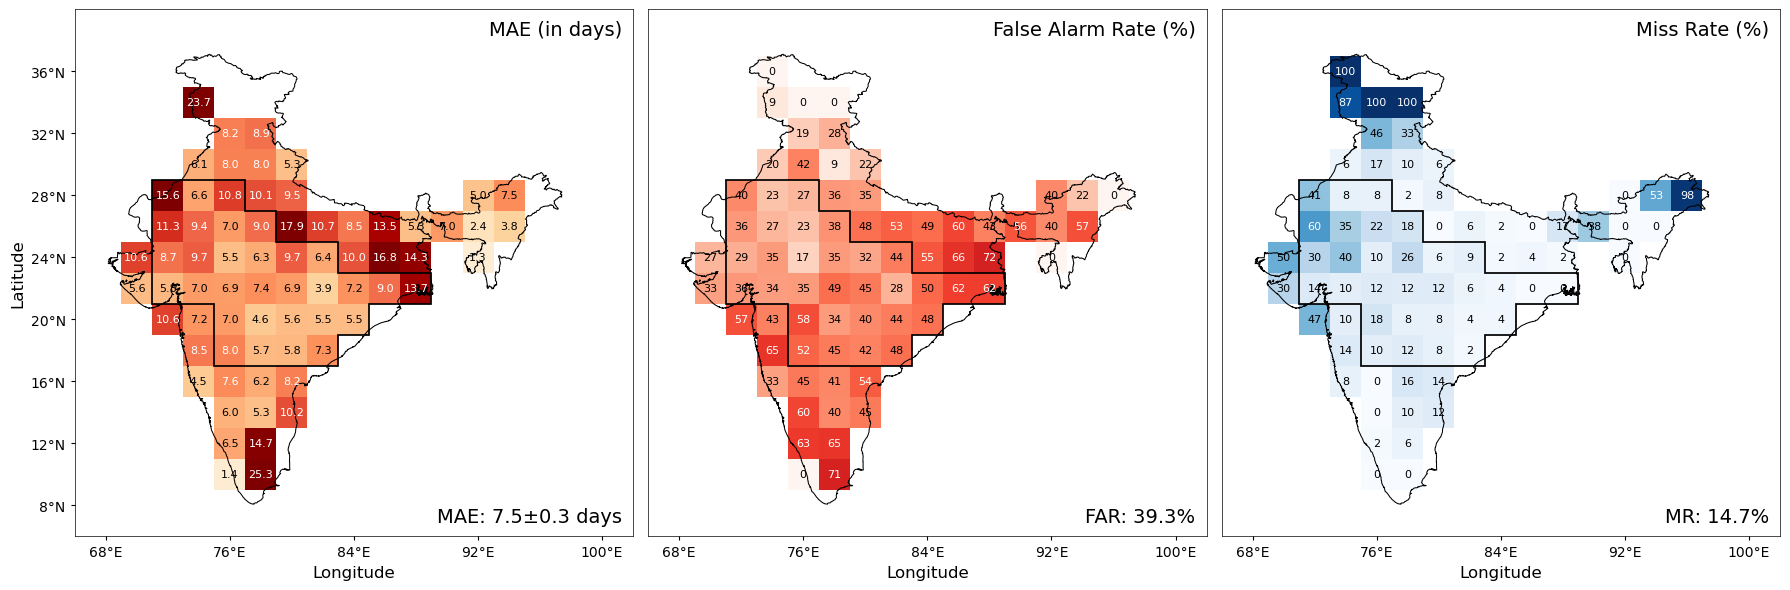


=== CORE MONSOON ZONE (CMZ) AVERAGES ===
CMZ Mean MAE (avg across years): 7.48 ± 0.33 days
CMZ False Alarm Rate: 39.3 %
CMZ Miss Rate: 14.7 %


(<Figure size 1800x600 with 3 Axes>,
 array([<Axes: xlabel='Longitude', ylabel='Latitude'>,
        <Axes: xlabel='Longitude'>, <Axes: xlabel='Longitude'>],
       dtype=object))

In [12]:
plot_spatial_metrics(spatial_metrics, figsize=(18, 6), save_path=None)

In [17]:
ds = get_s2s_prob_twice_weekly(2023, s2s_data_dir)

In [18]:
ds

<xarray.DataArray 'tp' (member: 51, step: 44, init_time: 26, lat: 8, lon: 9)> Size: 17MB
[4200768 values with dtype=float32]
Coordinates:
  * init_time  (init_time) datetime64[ns] 208B 2023-05-02 ... 2023-07-29
  * lon        (lon) float64 72B 68.0 72.0 76.0 80.0 84.0 88.0 92.0 96.0 100.0
  * lat        (lat) float64 64B 8.0 12.0 16.0 20.0 24.0 28.0 32.0 36.0
  * member     (member) int64 408B 1 2 3 4 5 6 7 8 9 ... 44 45 46 47 48 49 50 51
  * step       (step) int64 352B 1 2 3 4 5 6 7 8 9 ... 37 38 39 40 41 42 43 44